# Seaborn Data Visualization 
Seaborn is a library for making statistical graphics in Python. **It builds on top of matplotlib and integrates closely with pandas** data structures.

This notebook provides a comprehensive exploration of the car dataset using various Seaborn visualization techniques.

## Table of Contents
1. Setup and Data Loading
2. Dataset Overview
3. Distribution Plots
4. Relationship Plots
5. Categorical Plots
6. Matrix Plots
7. Advanced Visualizations

## 1. Setup and Data Loading

In [ ]:
# Install required libraries
%pip install pandas numpy seaborn matplotlib

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better-looking plots
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load the dataset
df = pd.read_csv('car_dataset.csv')

# Clean column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(f"Dataset types: {df.dtypes}")
print("="*50)
print(f"Dataset shape: {df.shape}")
print("="*50)
print(f"Columns: {list(df.columns)}")
print("="*50)
df.head()

Dataset types: make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object
Dataset shape: (11914, 16)
Columns: ['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp']


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 2. Dataset Overview

In [7]:
# Display basic information
print("Dataset Information:")
print("="*50)
df.info()

print("\n\nBasic Statistics:")
print("="*50)
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


---
# SEABORN CHART TYPES - DETAILED EXPLORATION
---

## Chart 1: HISTPLOT - Distribution of a Single Variable

### Definition:
A histogram plot shows the distribution of a single numerical variable by dividing the data into bins and counting how many observations fall into each bin.

### When to Use:
- To understand the distribution of a continuous variable
- To identify skewness, outliers, or multiple peaks
- To see the frequency of values in different ranges

### Key Parameters:
- `bins`: Number of bins to divide the data
- `kde`: Add a kernel density estimate curve
- `hue`: Add categorical grouping

### Dataset Application:
Visualize the distribution of car prices (MSRP)

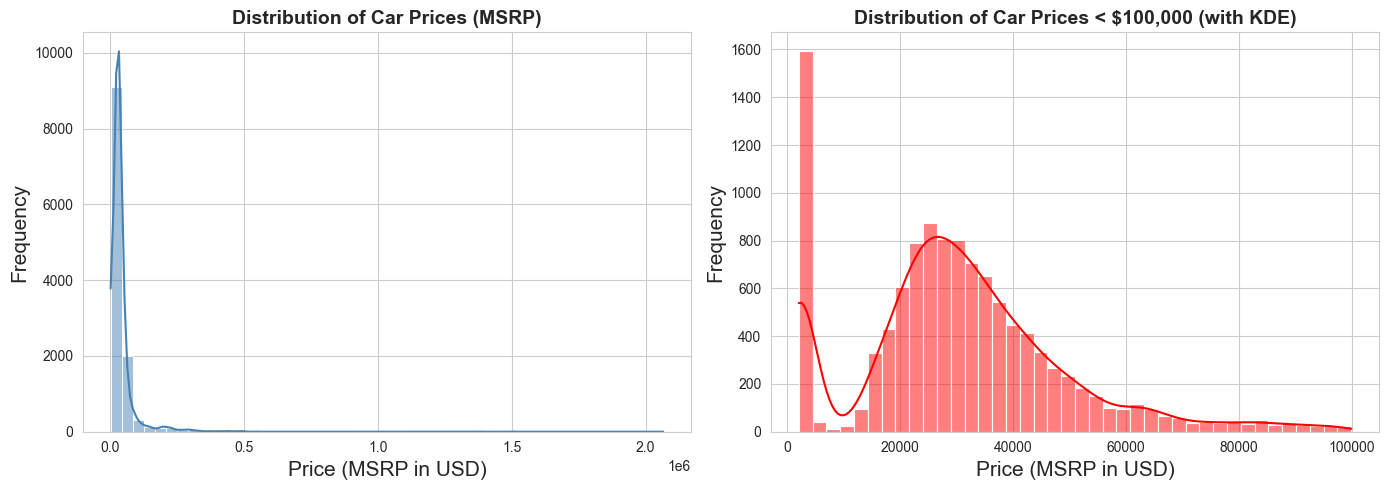

Interpretation:
- Left plot shows the full distribution with right skewness (most cars are cheaper)
- Right plot focuses on cars under $100k with a smoothed KDE curve showing the probability density


In [24]:
# Chart 1: Histplot - Distribution of MSRP
plt.figure(figsize=(14, 5))

# Plot 1: Basic histogram
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='msrp', bins=50, kde=True, color='steelblue')
plt.title('Distribution of Car Prices (MSRP)', fontsize=14, fontweight='bold')
plt.xlabel('Price (MSRP in USD)', fontsize=15)
plt.ylabel('Frequency', fontsize=15)

# Plot 2: Histogram with filtered data and Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.histplot(data=df[df.msrp < 100000], x='msrp', bins=40, kde=True, color='red')
plt.title('Distribution of Car Prices < $100,000 (with KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Price (MSRP in USD)', fontsize=15)
plt.ylabel('Frequency', fontsize=15)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Left plot shows the full distribution with right skewness (most cars are cheaper)")
print("- Right plot focuses on cars under $100k with a smoothed KDE curve showing the probability density")

## Chart 2: BOXPLOT - Distribution with Quartiles and Outliers

### Definition:
A box plot displays the distribution of data through quartiles, showing the median, upper/lower quartiles, and outliers.

### When to Use:
- To compare distributions across categories
- To identify outliers
- To see the spread and central tendency of data

### Components:
- Box: Represents the interquartile range (IQR) - middle 50% of data
- Line in box: Median (50th percentile)
- Whiskers: Extend to 1.5 * IQR
- Points: Outliers beyond whiskers

### Dataset Application:
Compare MSRP across different vehicle sizes

/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_9623/2605535886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='vehicle_size', y='msrp', palette='Set2')


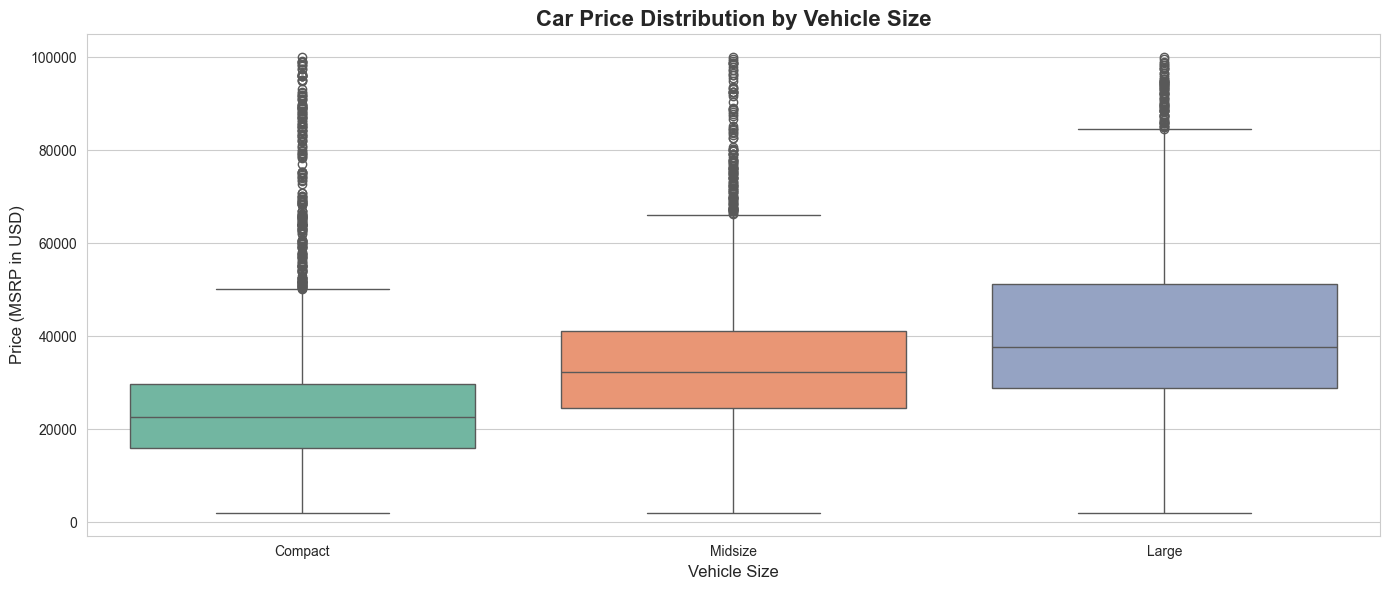

Interpretation:
- Each box shows the middle 50% of prices for that vehicle size
- The line inside the box is the median price
- Points above/below whiskers are outliers (unusually expensive/cheap cars)
- Compare median lines to see which size category tends to be more expensive


In [17]:
# Chart 2: Boxplot - MSRP by Vehicle Size
plt.figure(figsize=(14, 6))

# Filter for better visualization
df_filtered = df[df.msrp < 100000].copy()

sns.boxplot(data=df_filtered, x='vehicle_size', y='msrp', palette='Set2')
plt.title('Car Price Distribution by Vehicle Size', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle Size', fontsize=12)
plt.ylabel('Price (MSRP in USD)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Each box shows the middle 50% of prices for that vehicle size")
print("- The line inside the box is the median price")
print("- Points above/below whiskers are outliers (unusually expensive/cheap cars)")
print("- Compare median lines to see which size category tends to be more expensive")

## Chart 3: VIOLINPLOT - Distribution Shape with Density

### Definition:
A violin plot combines a box plot with a kernel density plot, showing the distribution shape rotated and mirrored.

### When to Use:
- To see the full distribution shape (not just quartiles)
- To compare distributions across categories
- To identify multiple peaks (bimodal/multimodal distributions)

### Advantages over Boxplot:
- Shows the probability density at different values
- Reveals distribution shapes that box plots hide
- Better for identifying bimodal distributions

### Dataset Application:
Compare highway MPG across different driven wheels types

/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_9623/724028400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='driven_wheels', y='highway_mpg', palette='muted', inner='box')


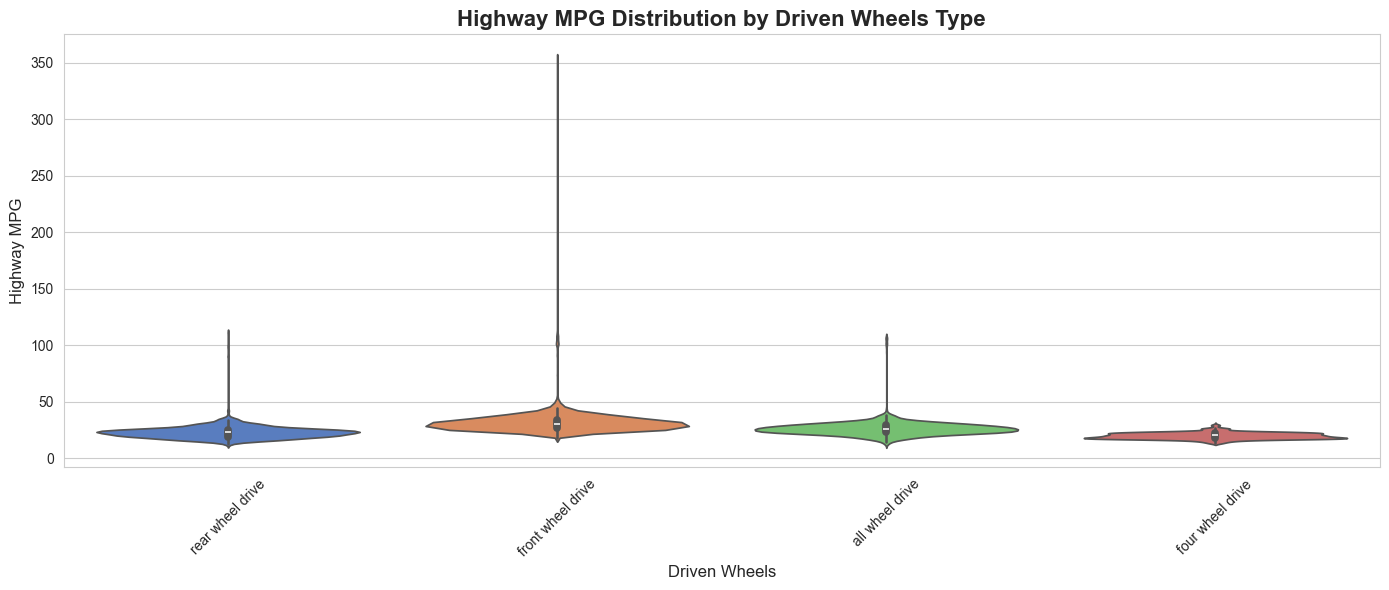

Interpretation:
- Width of violin shows density - wider means more cars with that MPG value
- The mini box plot inside shows quartiles
- Compare shapes: unimodal (one peak) vs bimodal (two peaks)
- Front-wheel drive cars tend to have better highway MPG than all-wheel drive


In [23]:
# Chart 3: Violinplot - Highway MPG by Driven Wheels
plt.figure(figsize=(14, 6))

sns.violinplot(data=df, x='driven_wheels', y='highway_mpg', palette='muted', inner='box')
plt.title('Highway MPG Distribution by Driven Wheels Type', fontsize=16, fontweight='bold')
plt.xlabel('Driven Wheels', fontsize=12)
plt.ylabel('Highway MPG', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Width of violin shows density - wider means more cars with that MPG value")
print("- The mini box plot inside shows quartiles")
print("- Compare shapes: unimodal (one peak) vs bimodal (two peaks)")
print("- Front-wheel drive cars tend to have better highway MPG than all-wheel drive")

## Chart 4: SCATTERPLOT - Relationship Between Two Variables

### Definition:
A scatter plot displays individual data points with two numerical variables on x and y axes.

### When to Use:
- To identify correlation between two variables
- To detect patterns, trends, or clusters
- To spot outliers in 2D space

### What to Look For:
- Positive correlation: Points trend upward
- Negative correlation: Points trend downward
- No correlation: Random scatter
- Clusters: Groups of points

### Dataset Application:
We'll examine the relationship between engine horsepower and price

In [ ]:
# Chart 4: Scatterplot - Engine HP vs MSRP
plt.figure(figsize=(14, 6))

# Filter for better visualization
df_scatter = df[(df.msrp < 150000) & (df.engine_hp < 600)].copy()

sns.scatterplot(data=df_scatter, x='engine_hp', y='msrp', 
                hue='vehicle_size', size='city_mpg', 
                sizes=(20, 200), alpha=0.6, palette='deep')
plt.title('Relationship: Engine Horsepower vs Car Price', fontsize=16, fontweight='bold')
plt.xlabel('Engine Horsepower', fontsize=12)
plt.ylabel('Price (MSRP in USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Positive correlation: Higher horsepower generally means higher price")
print("- Color (hue) shows vehicle size - larger vehicles tend to have more HP")
print("- Point size represents city MPG - larger points = better fuel efficiency")
print("- Note: High HP + low price or low HP + high price are interesting outliers")

## Chart 5: LINEPLOT - Trends Over Categories or Time

### Definition:
A line plot connects data points with lines, showing trends and changes across a continuous or ordered variable.

### When to Use:
- To show trends over time or ordered categories
- To compare multiple trends simultaneously
- To visualize aggregated data with confidence intervals

### Seaborn Features:
- Automatically calculates mean and confidence interval
- Can show multiple lines with hue parameter
- Shaded area shows uncertainty/variance

### Dataset Application:
We'll analyze how average car price changed over years by manufacturer

In [ ]:
# Chart 5: Lineplot - Average MSRP by Year for Top Manufacturers
plt.figure(figsize=(14, 6))

# Get top 5 manufacturers by count
top_makes = df['make'].value_counts().head(5).index
df_line = df[df['make'].isin(top_makes)].copy()

sns.lineplot(data=df_line, x='year', y='msrp', hue='make', 
             marker='o', markersize=6, linewidth=2.5)
plt.title('Average Car Price Trends by Year (Top 5 Manufacturers)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (MSRP in USD)', fontsize=12)
plt.legend(title='Manufacturer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Each line represents a different manufacturer")
print("- Upward slopes indicate price increases over years")
print("- Shaded areas show confidence intervals (data uncertainty)")
print("- Compare slopes to see which brands increased prices more aggressively")

## Chart 6: BARPLOT - Average Values Across Categories

### Definition:
A bar plot shows the mean (or other aggregate) of a numerical variable for different categories, with error bars showing confidence intervals.

### When to Use:
- To compare average values across categories
- To show aggregated data with uncertainty
- To rank categories by performance

### Difference from Count Plot:
- Barplot: Shows mean/aggregate of a numerical variable
- Countplot: Shows frequency/count of categories

### Dataset Application:
We'll compare average horsepower across different fuel types

In [ ]:
# Chart 6: Barplot - Average Engine HP by Fuel Type
plt.figure(figsize=(14, 6))

# Get top fuel types
top_fuel = df['engine_fuel_type'].value_counts().head(8).index
df_bar = df[df['engine_fuel_type'].isin(top_fuel)].copy()

sns.barplot(data=df_bar, x='engine_fuel_type', y='engine_hp', 
            palette='rocket', estimator='mean', ci=95)
plt.title('Average Engine Horsepower by Fuel Type', fontsize=16, fontweight='bold')
plt.xlabel('Engine Fuel Type', fontsize=12)
plt.ylabel('Average Horsepower', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Bar height shows the average (mean) horsepower for each fuel type")
print("- Black lines (error bars) show 95% confidence interval")
print("- Longer error bars indicate more variability in that category")
print("- Premium unleaded and flex-fuel vehicles tend to have higher average HP")

## Chart 7: COUNTPLOT - Frequency of Categories

### Definition:
A count plot shows the frequency (count) of observations in each category.

### When to Use:
- To see which categories are most/least common
- To understand data distribution across categories
- To identify imbalanced classes

### Key Features:
- Automatically counts occurrences
- Can be grouped by another category (hue)
- Works only with categorical data

### Dataset Application:
We'll count cars by vehicle style and size

In [ ]:
# Chart 7: Countplot - Number of Cars by Vehicle Style
plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='vehicle_style', hue='vehicle_size', 
              palette='Set3', order=df['vehicle_style'].value_counts().index[:10])
plt.title('Number of Cars by Vehicle Style (Grouped by Size)', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle Style', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vehicle Size', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Bar height shows how many cars exist in each style category")
print("- Colors (hue) break down counts by vehicle size")
print("- Sedan is the most common vehicle style in the dataset")
print("- This helps identify dataset imbalances (over/under-represented categories)")

## Chart 8: HEATMAP - Correlation Matrix

### Definition:
A heatmap displays data in a color-coded matrix, commonly used to show correlations between variables.

### When to Use:
- To identify correlations between multiple numerical variables
- To detect multicollinearity in features
- To visualize confusion matrices or pivot tables

### Color Interpretation:
- Dark colors (red/orange): Strong positive correlation (+1)
- Light colors (white): No correlation (0)
- Cool colors (blue): Strong negative correlation (-1)

### Dataset Application:
We'll create a correlation matrix of numerical features

In [ ]:
# Chart 8: Heatmap - Correlation Matrix
plt.figure(figsize=(12, 10))

# Select numerical columns
numerical_cols = ['engine_hp', 'engine_cylinders', 'highway_mpg', 
                  'city_mpg', 'popularity', 'msrp', 'year']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Values range from -1 (perfect negative correlation) to +1 (perfect positive correlation)")
print("- Diagonal is always 1 (variable perfectly correlates with itself)")
print("- Red cells: Variables increase together (e.g., engine_hp and msrp)")
print("- Blue cells: One increases as other decreases (e.g., engine_hp and highway_mpg)")
print("- Near-zero values: No linear relationship between variables")

## Chart 9: PAIRPLOT - Multiple Scatter Plots Matrix

### Definition:
A pair plot creates a grid of scatter plots for all pairs of numerical variables, with histograms on the diagonal.

### When to Use:
- To explore relationships between all numerical variables at once
- To identify patterns across multiple variable pairs
- To detect clusters or separability in data

### Components:
- Off-diagonal: Scatter plots (bivariate relationships)
- Diagonal: Histograms or KDE (univariate distributions)
- Optional hue: Color by category

### Dataset Application:
We'll examine relationships between key numerical features

In [ ]:
# Chart 9: Pairplot - Relationships Between Key Features
# Select subset for better performance
df_sample = df[['engine_hp', 'highway_mpg', 'city_mpg', 'msrp', 'vehicle_size']].dropna()
df_sample = df_sample[df_sample['msrp'] < 80000].sample(n=1000, random_state=42)

pairplot = sns.pairplot(df_sample, hue='vehicle_size', 
                        palette='husl', diag_kind='kde', 
                        plot_kws={'alpha': 0.6, 's': 30},
                        height=2.5)
pairplot.fig.suptitle('Pairwise Relationships Between Key Features', 
                      fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("Interpretation:")
print("- Each scatter plot shows the relationship between two variables")
print("- Diagonal shows distribution of individual variables (KDE curves)")
print("- Colors represent vehicle sizes - look for cluster separation")
print("- Strong linear patterns indicate correlation (positive or negative)")
print("- This plot helps identify which variables are most useful for prediction")

## Chart 10: JOINTPLOT - Bivariate with Marginal Distributions

### Definition:
A joint plot shows the relationship between two variables with their individual distributions on the margins.

### When to Use:
- To examine one specific bivariate relationship in detail
- To see both correlation and individual distributions simultaneously
- To add regression lines or density contours

### Plot Types:
- scatter: Traditional scatter plot
- hex: Hexagonal binning for dense data
- kde: Kernel density estimation (contours)
- reg: Scatter with regression line

### Dataset Application:
We'll explore the relationship between engine cylinders and horsepower

In [ ]:
# Chart 10: Jointplot - Engine Cylinders vs Horsepower
df_joint = df[['engine_cylinders', 'engine_hp']].dropna()
df_joint = df_joint[(df_joint['engine_cylinders'] <= 12) & (df_joint['engine_hp'] < 600)]

joint = sns.jointplot(data=df_joint, x='engine_cylinders', y='engine_hp', 
                      kind='reg', height=8, color='mediumseagreen',
                      marginal_kws={'bins': 30, 'kde': True})
joint.fig.suptitle('Relationship: Engine Cylinders vs Horsepower (with regression)', 
                   fontsize=14, fontweight='bold', y=1.02)
joint.set_axis_labels('Number of Engine Cylinders', 'Engine Horsepower', fontsize=12)
plt.show()

print("Interpretation:")
print("- Center: Scatter plot with regression line showing the trend")
print("- Top margin: Distribution of engine cylinders (most cars have 4 or 6 cylinders)")
print("- Right margin: Distribution of horsepower values")
print("- Strong positive correlation: More cylinders = more horsepower")
print("- Regression line helps predict HP based on cylinder count")

## Chart 11: KDEPLOT - Kernel Density Estimation

### Definition:
A KDE plot shows the probability density function of a continuous variable using kernel smoothing.

### When to Use:
- To visualize smooth probability distributions
- To compare distributions between groups
- To identify multiple peaks (modes) in data
- For bivariate density (2D contour plots)

### Advantages:
- Smoother than histograms (no binning artifacts)
- Better for comparing overlapping distributions
- Can show 2D density with contours

### Dataset Application:
We'll compare price distributions across vehicle sizes and create a 2D density plot

In [ ]:
# Chart 11: KDEplot - Price Distribution by Vehicle Size
plt.figure(figsize=(14, 6))

# Plot 1: Multiple KDE curves
plt.subplot(1, 2, 1)
for size in df['vehicle_size'].dropna().unique():
    subset = df[df['vehicle_size'] == size]['msrp']
    subset = subset[(subset > 0) & (subset < 100000)]
    sns.kdeplot(data=subset, label=size, linewidth=2.5, alpha=0.7)

plt.title('Price Distribution by Vehicle Size (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Price (MSRP in USD)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Vehicle Size')
plt.grid(True, alpha=0.3)

# Plot 2: 2D KDE (bivariate)
plt.subplot(1, 2, 2)
df_kde = df[(df['msrp'] < 100000) & (df['engine_hp'] < 500)].dropna(subset=['msrp', 'engine_hp'])
sns.kdeplot(data=df_kde, x='engine_hp', y='msrp', 
            fill=True, cmap='viridis', levels=15, alpha=0.8)
plt.title('2D Density: Horsepower vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Engine Horsepower', fontsize=12)
plt.ylabel('Price (MSRP in USD)', fontsize=12)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Left plot: Smooth curves show probability density for each vehicle size")
print("  * Peak height shows where most cars are priced")
print("  * Curve width shows the spread of prices")
print("- Right plot: Contour map shows joint density of HP and price")
print("  * Brighter areas = more data concentration")
print("  * Reveals the typical HP-price combinations in the dataset")

## Chart 12: SWARMPLOT - Categorical Scatter with No Overlap

### Definition:
A swarm plot displays all data points adjusted along the categorical axis to avoid overlap, showing the distribution and individual observations.

### When to Use:
- With small to medium datasets (< 1000 points per category)
- To show every individual observation
- To see both distribution shape and actual data points
- To identify exact values and outliers

### Advantages:
- No data aggregation - see every point
- Shows distribution shape like violin plots
- Easier to spot patterns than scatter plots

### Dataset Application:
We'll visualize highway MPG for different driven wheels types

In [ ]:
# Chart 12: Swarmplot - Highway MPG by Driven Wheels
plt.figure(figsize=(14, 6))

# Sample data for better visualization
df_swarm = df[['driven_wheels', 'highway_mpg']].dropna()
df_swarm = df_swarm.groupby('driven_wheels').sample(n=200, random_state=42)

sns.swarmplot(data=df_swarm, x='driven_wheels', y='highway_mpg', 
              palette='tab10', size=5, alpha=0.7)
plt.title('Highway MPG Distribution by Driven Wheels (All Points Visible)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Driven Wheels Type', fontsize=12)
plt.ylabel('Highway MPG', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Each dot represents one car in the dataset")
print("- Points are spread horizontally to avoid overlap")
print("- Vertical position shows the actual MPG value")
print("- Dense regions show common values; sparse regions show rare values")
print("- Great for seeing the exact distribution without aggregation")

## Chart 13: STRIPPLOT - Categorical Scatter (Simple)

### Definition:
A strip plot is similar to swarm plot but simpler - it draws points along the categorical axis with optional jitter to reduce overlap.

### When to Use:
- With large datasets where swarm plot is too slow
- To show individual observations
- When exact positioning is less important
- As an overlay on box/violin plots

### Key Parameter:
- jitter: Adds random noise to separate overlapping points (0 to 1)

### Dataset Application:
We'll show car prices across different manufacturers with strip plot

In [ ]:
# Chart 13: Stripplot with Boxplot Overlay
plt.figure(figsize=(14, 6))

# Get top manufacturers
top_makes = df['make'].value_counts().head(8).index
df_strip = df[df['make'].isin(top_makes) & (df['msrp'] < 100000)].copy()

# Boxplot as background
sns.boxplot(data=df_strip, x='make', y='msrp', 
            palette='pastel', width=0.6)

# Stripplot overlay
sns.stripplot(data=df_strip, x='make', y='msrp', 
              color='darkblue', alpha=0.3, size=3, jitter=0.3)

plt.title('Car Prices by Manufacturer (Box + Strip Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Price (MSRP in USD)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Box plot shows quartiles and outliers (summary statistics)")
print("- Blue dots show actual individual car prices (raw data)")
print("- Jitter spreads overlapping points horizontally for visibility")
print("- Combined plot shows both summary and detail")
print("- Useful for seeing if outliers in box plot are truly exceptional or part of a cluster")

## Chart 14: REGPLOT - Regression with Scatter

### Definition:
A regression plot combines a scatter plot with a fitted regression line and confidence interval.

### When to Use:
- To visualize linear relationships
- To show trend lines with uncertainty
- To identify outliers from the trend
- For simple bivariate regression analysis

### Components:
- Scatter points: Actual observations
- Line: Fitted regression line (y = mx + b)
- Shaded area: 95% confidence interval

### Dataset Application:
We'll examine how city and highway MPG relate to each other

In [ ]:
# Chart 14: Regplot - City MPG vs Highway MPG
plt.figure(figsize=(14, 6))

# Plot 1: Basic regplot
plt.subplot(1, 2, 1)
df_reg = df[['city_mpg', 'highway_mpg']].dropna()
sns.regplot(data=df_reg, x='city_mpg', y='highway_mpg', 
            scatter_kws={'alpha': 0.4, 's': 30}, 
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Relationship: City MPG vs Highway MPG', fontsize=14, fontweight='bold')
plt.xlabel('City MPG', fontsize=12)
plt.ylabel('Highway MPG', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 2: Year vs MSRP
plt.subplot(1, 2, 2)
df_reg2 = df[['year', 'msrp']].dropna()
df_reg2 = df_reg2[df_reg2['msrp'] < 100000]
sns.regplot(data=df_reg2, x='year', y='msrp', 
            scatter_kws={'alpha': 0.3, 's': 20}, 
            line_kws={'color': 'darkgreen', 'linewidth': 2},
            order=2)  # Polynomial regression (2nd order)
plt.title('Relationship: Year vs Price (Polynomial)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (MSRP in USD)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Left plot: Strong positive linear correlation between city and highway MPG")
print("  * Points close to line = good fit")
print("  * Points far from line = outliers or unusual cars")
print("- Right plot: Shows how car prices changed over years (polynomial fit)")
print("  * Curved line captures non-linear trends")
print("- Shaded areas show confidence - wider = more uncertainty")

## Chart 15: FACETGRID - Multiple Subplots by Category

### Definition:
FacetGrid creates a matrix of plots, where each subplot shows data for a specific category or combination of categories.

### When to Use:
- To compare patterns across multiple categories
- To avoid overcrowded plots with too many groups
- To create small multiples for easy comparison

### Parameters:
- row: Variable to split into rows
- col: Variable to split into columns  
- hue: Variable for color coding within each plot

### Dataset Application:
We'll create multiple histograms of price by vehicle size and fuel type

In [ ]:
# Chart 15: FacetGrid - Price Distribution by Vehicle Size and Driven Wheels
df_facet = df[(df['msrp'] < 80000) & 
              (df['vehicle_size'].notna()) & 
              (df['driven_wheels'].notna())].copy()

# Create FacetGrid
g = sns.FacetGrid(df_facet, col='vehicle_size', row='driven_wheels', 
                  height=3, aspect=1.2, margin_titles=True)
g.map(sns.histplot, 'msrp', bins=30, kde=True, color='steelblue')
g.set_axis_labels('Price (MSRP in USD)', 'Frequency')
g.fig.subplots_adjust(top=0.93)
g.fig.suptitle('Price Distribution Across Vehicle Size and Driven Wheels', 
               fontsize=16, fontweight='bold')
plt.show()

print("Interpretation:")
print("- Each subplot shows price distribution for a specific combination")
print("- Rows represent different driven wheels types")
print("- Columns represent different vehicle sizes")
print("- Compare distributions across subplots to see patterns")
print("- Example: Large all-wheel drive vehicles tend to have higher, more spread prices")
print("- FacetGrid prevents overcrowding and makes comparisons easier")

---
## SUMMARY: When to Use Each Chart Type
---

### Quick Reference Guide:

| Chart Type | Primary Use | Best For | Data Type |
|------------|-------------|----------|------------|
| **Histplot** | Distribution of single variable | Understanding value frequency | Numerical |
| **Boxplot** | Distribution summary with outliers | Comparing distributions across categories | Numerical + Categorical |
| **Violinplot** | Distribution shape with density | Seeing full distribution curves | Numerical + Categorical |
| **Scatterplot** | Relationship between two variables | Identifying correlations | Numerical x Numerical |
| **Lineplot** | Trends over time/order | Time series, sequential data | Numerical over Time/Order |
| **Barplot** | Average values across categories | Comparing means | Numerical + Categorical |
| **Countplot** | Frequency of categories | Counting observations | Categorical |
| **Heatmap** | Correlation or matrix data | Finding relationships between many variables | Numerical matrix |
| **Pairplot** | Multiple relationships | Exploratory analysis of all pairs | Multiple Numerical |
| **Jointplot** | Single bivariate relationship + margins | Detailed analysis of two variables | Numerical x Numerical |
| **KDEplot** | Smooth probability density | Comparing smooth distributions | Numerical |
| **Swarmplot** | All individual points visible | Small datasets, showing every point | Numerical + Categorical |
| **Stripplot** | Individual points with jitter | Large datasets, overlay on box/violin | Numerical + Categorical |
| **Regplot** | Linear regression fit | Showing trends with uncertainty | Numerical x Numerical |
| **FacetGrid** | Multiple subplots by category | Comparing patterns across groups | Any + Categorical splits |

---
## Feature Comparison Matrix
---

In [ ]:
# Create a summary of which charts work with which features
feature_chart_mapping = {
    'msrp': ['histplot', 'boxplot', 'violinplot', 'scatterplot', 'regplot', 'kdeplot'],
    'engine_hp': ['histplot', 'scatterplot', 'regplot', 'jointplot', 'pairplot'],
    'highway_mpg': ['histplot', 'violinplot', 'swarmplot', 'stripplot', 'regplot'],
    'city_mpg': ['histplot', 'scatterplot', 'regplot', 'pairplot'],
    'year': ['lineplot', 'regplot', 'scatterplot'],
    'make': ['countplot', 'barplot', 'stripplot'],
    'vehicle_size': ['countplot', 'boxplot', 'violinplot', 'facetgrid'],
    'vehicle_style': ['countplot', 'barplot'],
    'driven_wheels': ['countplot', 'violinplot', 'swarmplot', 'facetgrid'],
    'engine_fuel_type': ['countplot', 'barplot']
}

print("\n" + "="*80)
print("FEATURE-TO-CHART MAPPING GUIDE")
print("="*80 + "\n")

for feature, charts in feature_chart_mapping.items():
    print(f"📊 {feature.upper()}:")
    print(f"   Recommended charts: {', '.join(charts)}")
    print()

print("="*80)

---
## Advanced Visualization: Combined Dashboard
---

/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_9623/449694295.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, ax=ax2, palette='viridis')
/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_9623/449694295.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='vehicle_size', ax=ax3, palette='Set2', order=df['vehicle_size'].value_counts().index)
/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_9623/449694295.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

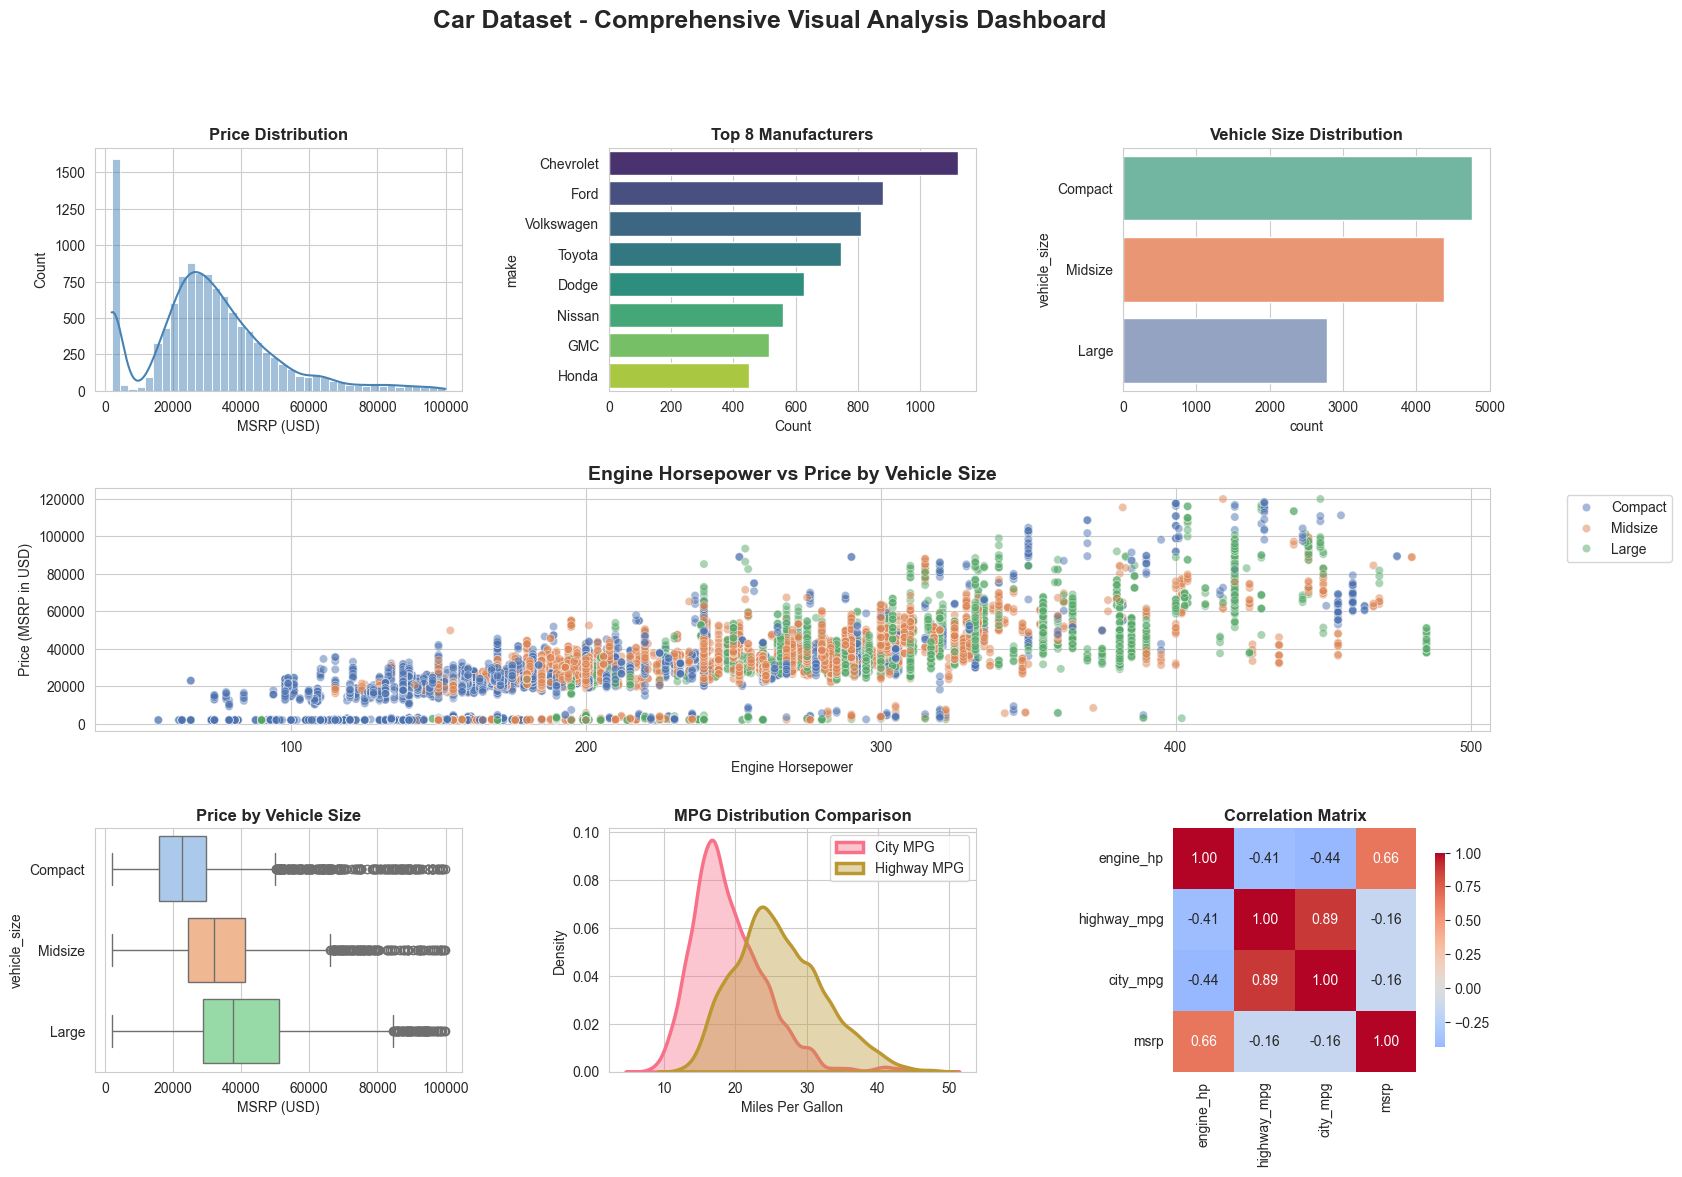

Dashboard created successfully!
This dashboard combines multiple visualization types for comprehensive analysis.


In [20]:
# Create a comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.4)

# Plot 1: Price distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=df[df.msrp < 100000], x='msrp', bins=40, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Price Distribution', fontweight='bold')
ax1.set_xlabel('MSRP (USD)')

# Plot 2: Top manufacturers
ax2 = fig.add_subplot(gs[0, 1])
top_makes = df['make'].value_counts().head(8)
sns.barplot(x=top_makes.values, y=top_makes.index, ax=ax2, palette='viridis')
ax2.set_title('Top 8 Manufacturers', fontweight='bold')
ax2.set_xlabel('Count')

# Plot 3: Vehicle size distribution
ax3 = fig.add_subplot(gs[0, 2])
sns.countplot(data=df, y='vehicle_size', ax=ax3, palette='Set2', order=df['vehicle_size'].value_counts().index)
ax3.set_title('Vehicle Size Distribution', fontweight='bold')

# Plot 4: HP vs Price scatter
ax4 = fig.add_subplot(gs[1, :])
df_scatter = df[(df.msrp < 120000) & (df.engine_hp < 500)]
sns.scatterplot(data=df_scatter, x='engine_hp', y='msrp', hue='vehicle_size', 
                alpha=0.5, ax=ax4, palette='deep')
ax4.set_title('Engine Horsepower vs Price by Vehicle Size', fontweight='bold', fontsize=14)
ax4.set_xlabel('Engine Horsepower')
ax4.set_ylabel('Price (MSRP in USD)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 5: Price by vehicle size
ax5 = fig.add_subplot(gs[2, 0])
sns.boxplot(data=df[df.msrp < 100000], y='vehicle_size', x='msrp', ax=ax5, palette='pastel')
ax5.set_title('Price by Vehicle Size', fontweight='bold')
ax5.set_xlabel('MSRP (USD)')

# Plot 6: MPG comparison
ax6 = fig.add_subplot(gs[2, 1])
mpg_data = df[['city_mpg', 'highway_mpg']].dropna()
mpg_data = mpg_data[(mpg_data['city_mpg'] < 50) & (mpg_data['highway_mpg'] < 60)]
sns.kdeplot(data=mpg_data['city_mpg'], label='City MPG', ax=ax6, linewidth=2.5, fill=True, alpha=0.4)
sns.kdeplot(data=mpg_data['highway_mpg'], label='Highway MPG', ax=ax6, linewidth=2.5, fill=True, alpha=0.4)
ax6.set_title('MPG Distribution Comparison', fontweight='bold')
ax6.set_xlabel('Miles Per Gallon')
ax6.legend()

# Plot 7: Correlation heatmap (small)
ax7 = fig.add_subplot(gs[2, 2])
corr_cols = ['engine_hp', 'highway_mpg', 'city_mpg', 'msrp']
corr_small = df[corr_cols].corr()
sns.heatmap(corr_small, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax7, cbar_kws={'shrink': 0.8})
ax7.set_title('Correlation Matrix', fontweight='bold')

fig.suptitle('Car Dataset - Comprehensive Visual Analysis Dashboard', 
             fontsize=18, fontweight='bold', y=0.995)

plt.show()

print("Dashboard created successfully!")
print("This dashboard combines multiple visualization types for comprehensive analysis.")

---
## Best Practices
---

### Key Takeaways:

1. **Choose the right chart for your data type:**
   - Numerical → histplot, boxplot, violinplot, scatterplot
   - Categorical → countplot, barplot
   - Both → boxplot, violinplot with grouping

2. **Consider your question:**
   - Distribution? → histplot, kdeplot, violinplot
   - Comparison? → boxplot, barplot, facetgrid
   - Relationship? → scatterplot, regplot, jointplot
   - Correlation? → heatmap, pairplot

3. **Always customize for clarity:**
   - Add clear titles and axis labels
   - Use appropriate color palettes
   - Include legends when using hue
   - Adjust figure size for readability

4. **Iterative exploration:**
   - Start with simple plots (histplot, countplot)
   - Move to relationships (scatterplot, regplot)
   - Use advanced plots for specific questions (facetgrid, pairplot)

5. **Performance considerations:**
   - Sample large datasets for swarmplot
   - Use hexbin or kde for very dense scatterplots
   - Limit pairplot to key features

### Next Steps:
- Experiment with different parameters
- Combine multiple plot types
- Create custom color palettes
- Export high-quality figures for reports

**Happy Visualizing! 📊📈**